# Neural Generalized FOGAS on the 5 x 5 Grids

This additional notebook tests the general parametrized solver with neural residual-weighting, action-value, and policy functions on the deterministic and stochastic 5 x 5 gridworlds. It provides a finite-state nonlinear check before the continuous-state Mountain Car experiment reported in the thesis.

For each grid, the notebook defines the environment and fixed offline dataset, builds small neural networks from normalized state descriptors, runs a representative Generalized FOGAS configuration, and evaluates both the solver policy and its greedy version. The exhaustive neural parameter selection is performed by the corresponding scripts in `../scripts/hyperparam_grids/5grid/`.

**Inputs.** The notebook uses `5grid.csv` and `5grid_stochastic.csv` from `data/datasets/generalization/`; the data-collection cells show how those fixed batches were created.

**Outputs.** The deterministic and stochastic sections display the grid, training diagnostics, and learned policies for representative neural configurations.

In [31]:
%load_ext autoreload
%autoreload 2

import os
import random
import numpy as np
import pandas as pd
import sys
import torch
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def find_root(current_path):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / "src" / "rl_methods").exists() and (parent / "data").exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())

DATASETS_DIR = PROJECT_ROOT / "data" / "datasets" / "generalization"
RESULTS_DIR = PROJECT_ROOT / "data" / "results" / "generalization"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Add project root to the Python path
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from rl_methods.mdp import DiscreteMDP, Planner
from rl_methods.fogas import FOGASEvaluator, FOGASHyperOptimizer
from rl_methods.fogas_generalization import *
from rl_methods.fogas_generalization import (
    FinalLinearSolver,
    TabularFeatures,
    LinearFunction,
    LinearQFunction,
)
from rl_methods.data_collection import DiscreteDataBuffer
from rl_methods.fogas import FOGASEvaluator



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 5grid

The deterministic grid provides a controlled test of whether the general solver can optimize all three neural parametrizations from a fixed tabular-state dataset.

In [32]:
states = torch.arange(25, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.99
x_0 = 0

dataset_path_5grid = str(DATASETS_DIR / "5grid.csv")

grid_size = 5
goal_grid = 24

wall_states = {6, 7, 12}
terminal_states = {goal_grid}


def state_to_pos(s):
    return divmod(int(s), grid_size)


def pos_to_state(row, col):
    return row * grid_size + col


def move_deterministic(s, a):
    s = int(s)
    a = int(a)

    if s in terminal_states:
        return s

    row, col = state_to_pos(s)

    if a == 0:      # Up
        new_row, new_col = row - 1, col
    elif a == 1:    # Down
        new_row, new_col = row + 1, col
    elif a == 2:    # Left
        new_row, new_col = row, col - 1
    elif a == 3:    # Right
        new_row, new_col = row, col + 1
    else:
        raise ValueError("action must be in {0, 1, 2, 3}")

    if not (0 <= new_row < grid_size and 0 <= new_col < grid_size):
        return s

    sp = pos_to_state(new_row, new_col)

    if sp in wall_states:
        return s

    return sp


def next_state(s, a):
    return move_deterministic(s, a)


def transition_fn(s, a):
    probs = torch.zeros(N, dtype=torch.float64)
    probs[next_state(s, a)] = 1.0
    return probs


def reward_fn(s, a):
    sp = next_state(s, a)

    if sp == goal_grid:
        return 1.0

    return -0.01


mdp = DiscreteMDP(
    states=states,
    actions=actions,
    gamma=gamma,
    x0=x_0,
    reward_fn=reward_fn,
    transition_fn=transition_fn,
    terminal_states=list(terminal_states),
).to(DEVICE)

planner = Planner(mdp)

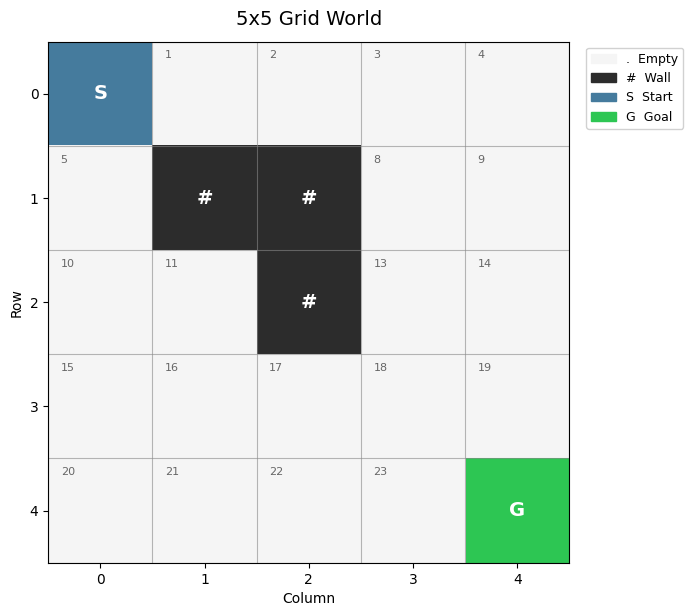

In [33]:
def plot_5grid(values=None, policy=None, title="5x5 Grid World"):
    grid_data = np.full((grid_size, grid_size), ".", dtype="<U1")

    for s in wall_states:
        r, c = state_to_pos(s)
        grid_data[r, c] = "#"

    r, c = state_to_pos(x_0)
    grid_data[r, c] = "S"

    r, c = state_to_pos(goal_grid)
    grid_data[r, c] = "G"

    mapping = {".": 0, "#": 1, "S": 2, "G": 3}
    labels = {0: "Empty", 1: "Wall", 2: "Start", 3: "Goal"}
    colors = ["#F5F5F5", "#2C2C2C", "#457B9D", "#2DC653"]

    numeric_grid = np.vectorize(mapping.get)(grid_data)
    cmap = mcolors.ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(
        numeric_grid,
        cmap=cmap,
        vmin=0,
        vmax=3,
        interpolation="nearest",
        origin="upper",
    )

    ax.set_xticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.grid(which="minor", color="#888888", linewidth=0.8, alpha=0.6)
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.set_xticks(np.arange(grid_size))
    ax.set_yticks(np.arange(grid_size))
    ax.set_xlabel("Column", fontsize=10)
    ax.set_ylabel("Row", fontsize=10)

    if values is not None:
        if hasattr(values, "detach"):
            values = values.detach().cpu().numpy()
        values = np.asarray(values).reshape(-1)

    if policy is not None:
        if hasattr(policy, "detach"):
            policy = policy.detach().cpu().numpy()
        policy = np.asarray(policy)
        best_actions = policy.argmax(axis=1) if policy.ndim == 2 else policy

    arrow_delta = {
        0: (0.0, -0.28),  # Up
        1: (0.0, 0.28),   # Down
        2: (-0.28, 0.0),  # Left
        3: (0.28, 0.0),   # Right
    }

    for s in range(N):
        r, c = state_to_pos(s)

        if s == goal_grid:
            ax.text(c, r, "G", ha="center", va="center", fontsize=14, fontweight="bold", color="white")
        elif s in wall_states:
            ax.text(c, r, "#", ha="center", va="center", fontsize=14, fontweight="bold", color="white")
        elif s == x_0:
            ax.text(c, r, "S", ha="center", va="center", fontsize=14, fontweight="bold", color="white")
        else:
            ax.text(c - 0.38, r - 0.34, str(s), fontsize=8, color="#666666")

        if values is not None and s not in wall_states:
            ax.text(c, r + 0.28, f"{values[s]:.2f}", ha="center", va="center", fontsize=9)

        if policy is not None and s not in terminal_states and s not in wall_states:
            dx, dy = arrow_delta[int(best_actions[s])]
            ax.arrow(
                c,
                r,
                dx,
                dy,
                head_width=0.10,
                head_length=0.10,
                fc="black",
                ec="black",
                linewidth=1.4,
                length_includes_head=True,
                zorder=5,
            )

    patches = [
        mpatches.Patch(color=colors[i], label=f"{symbol}  {labels[i]}")
        for symbol, i in mapping.items()
    ]

    ax.legend(
        handles=patches,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=9,
        framealpha=0.9,
    )

    ax.set_title(title, fontsize=14, pad=12)
    plt.tight_layout()
    plt.show()


plot_5grid()

## Data collection

The same mixed behaviour policy used by the linear experiment creates the fixed batch, keeping the comparison focused on the parametrization rather than on different data.

In [34]:
# Initialize the clean collector.
# every episode starts from state 0.
collector = DiscreteDataBuffer(
    mdp=mdp,
    reset_probs={"custom": 1.0},
    initial_states=[x_0],              
    restricted_states=wall_states,     
    max_steps=50,
    terminal_states={goal_grid},
    seed=SEED,
)

# Epsilon-greedy around the optimal policy.
# epsilon=0.3 means 70% planner.pi_star, 30% random action.
epsilon_policy = (planner.pi_star, 0.3)

df = collector.collect(
    policies=[epsilon_policy, "random"],
    proportions=[0.9, 0.1],
    n_steps=8000,
    extra_terminal_steps=3,
    episode_based=True,
    save_path=str(dataset_path_5grid),
    verbose=True,
)

df.head()

Collected 8000 transitions over 461 episodes.
Policy distribution:
policy_id
0    0.746
1    0.254
Name: proportion, dtype: float64
Reset mode distribution:
reset_mode
custom    1.0
Name: proportion, dtype: float64
Saved FOGAS dataset to /shared/home/mauro.diaz/work/FOGAS/data/datasets/generalization/5grid.csv


,episode,step,state,action,reward,next_state,policy_id,reset_mode,restricted_start
0,0,0,0,1,-0.01,5,0,custom,False
1,0,1,5,1,-0.01,10,0,custom,False
2,0,2,10,3,-0.01,11,0,custom,False
3,0,3,11,1,-0.01,16,0,custom,False
4,0,4,16,1,-0.01,21,0,custom,False


## Solver

Normalized grid coordinates are passed to small neural networks for the residual-weighting function, action-value function, and policy. The selected seed and configuration make the representative run reproducible.

In [35]:
NN_SEED = 123
EVAL_SEED = 42

random.seed(NN_SEED)
np.random.seed(NN_SEED)
torch.manual_seed(NN_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(NN_SEED)

state_inputs = torch.tensor(
    [[r / 4.0, c / 4.0] for r in range(grid_size) for c in range(grid_size)],
    dtype=torch.float64,
)

hidden_sizes = (8,)

u_param = NeuralUParam(
    StateActionMLPModule(
        n_states=N,
        n_actions=A,
        state_inputs=state_inputs,
        hidden_sizes=hidden_sizes,
        dtype=torch.float64,
    )
)

q_param = NeuralQParam(
    StateActionMLPModule(
        n_states=N,
        n_actions=A,
        state_inputs=state_inputs,
        hidden_sizes=hidden_sizes,
        dtype=torch.float64,
    )
)

policy_param = NeuralPolicyParam(
    StateMLPPolicyModule(
        n_states=N,
        n_actions=A,
        state_inputs=state_inputs,
        hidden_sizes=hidden_sizes,
        dtype=torch.float64,
    )
)

solver_e = FinalParametrizedSolver(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    x0=x_0,
    csv_path=dataset_path_5grid,
    u_param=u_param,
    q_param=q_param,
    policy_param=policy_param,
    seed=NN_SEED,
    device=DEVICE,

    theta_include_beta_cov=False,

    theta_mode="reg_fixed",
    theta_lambda=1e-3,
    theta_optimizer="adam",
    theta_inner_steps=3,
    theta_lr=3e-3,
    theta_start_mode="warm",

    beta_update="fogas_diag",
    beta_reg=1e-4,
)

solver_e.run(
    alpha=1e-3,
    eta=3e-5,
    rho=0.01,
    policy_optimizer="adam",
    policy_gradient="exact",
    reinforce_samples=1,
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    T=1000,
    state_weight_update="normal",
)

mdp.print_policy(solver_e.pi)

evaluator = FOGASEvaluator(
    solver=solver_e,
    mdp=mdp,
    planner=planner,
)

solver_stats = evaluator.average_return_stats(
    policy_mode="solver",
    num_trajectories=100,
    max_steps=20,
    seed=EVAL_SEED,
    terminal_states=terminal_states,
    compare_with_optimal=True,
)

greedy_stats = evaluator.average_return_stats(
    policy_mode="greedy",
    num_trajectories=100,
    max_steps=20,
    seed=EVAL_SEED,
    terminal_states=terminal_states,
    compare_with_optimal=True,
)

print(f"Solver avg reward:  {solver_stats['policy']:.4f} +- {solver_stats['policy_std']:.4f}")
print(f"Greedy avg reward:  {greedy_stats['policy']:.4f} +- {greedy_stats['policy_std']:.4f}")
print(f"Optimal avg reward: {solver_stats['optimal']:.4f} +- {solver_stats['optimal_std']:.4f}")

[FinalParametrizedSolver] Iter 1/1000 iter=0 total_loss=-9.791755e-02 policy_objective=-8.612625e-03 beta_objective=-9.747879e-02 q_objective=-1.146592e-02 policy_grad_norm=2.929940e-02 policy_direction_norm=2.929940e-02 beta_grad_norm=4.058274e-01 beta_direction_norm=2.017986e+01 theta_grad_norm=8.313617e-02 theta_norm=1.883720e+00 theta_mode=reg_fixed theta_optimizer=adam theta_start_mode=warm theta_lambda=1.000000e-03 theta_lr=3.000000e-03 theta_include_beta_cov=False policy_optimizer=adam policy_gradient=exact policy_direction=adam_gradient reinforce_samples=1 D_theta=8.062258e+01 effective_D_theta=8.062258e+01 u_fast_path=False q_fast_path=False policy_fast_path=False beta_update=fogas_diag beta_diag_min=1.495232e-03 beta_diag_max=1.000100e+00
[FinalParametrizedSolver] Iter 51/1000 iter=50 total_loss=-3.390317e-01 policy_objective=3.629509e-01 beta_objective=-3.107118e-01 q_objective=-2.622666e-01 policy_grad_norm=4.634457e-01 policy_direction_norm=4.634457e-01 beta_grad_norm=1.65

# 5 stochastic grid

The neural experiment is repeated when the intended action is replaced randomly with probability 0.2. This checks the nonlinear implementation under the same transition noise used in the thesis ablations.

In [ ]:
states = torch.arange(25, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9
x_0 = 0

dataset_path_5grid_stoch = str(DATASETS_DIR / "5grid_stochastic.csv")

grid_size = 5
goal_grid = 24
pit_grid = 18

wall_states = {6, 7, 12}
terminal_states = {goal_grid, pit_grid}


def state_to_pos(s):
    return divmod(int(s), grid_size)


def pos_to_state(row, col):
    return row * grid_size + col


def move_deterministic(s, a):
    s = int(s)
    a = int(a)

    if s in terminal_states:
        return s

    row, col = state_to_pos(s)

    if a == 0:      # Up
        new_row, new_col = row - 1, col
    elif a == 1:    # Down
        new_row, new_col = row + 1, col
    elif a == 2:    # Left
        new_row, new_col = row, col - 1
    elif a == 3:    # Right
        new_row, new_col = row, col + 1
    else:
        raise ValueError("action must be in {0, 1, 2, 3}")

    if not (0 <= new_row < grid_size and 0 <= new_col < grid_size):
        return s

    sp = pos_to_state(new_row, new_col)

    if sp in wall_states:
        return s

    return sp


def transition_probs(s, a, intended_prob=0.8):
    """
    Stochastic transition:
    intended_prob goes to the requested action.
    The remaining probability is uniform over all actions.
    
    With intended_prob=0.8 and A=4:
      intended action: 0.8 + 0.2 / 4 = 0.85
      other actions:   0.2 / 4 = 0.05 each
    """
    s = int(s)
    a = int(a)

    probs_by_state = {}

    for candidate_a in range(A):
        prob = (1.0 - intended_prob) / A
        if candidate_a == a:
            prob += intended_prob

        sp = move_deterministic(s, candidate_a)
        probs_by_state[sp] = probs_by_state.get(sp, 0.0) + prob

    return probs_by_state


def transition_fn(s, a):
    probs = torch.zeros(N, dtype=torch.float64)

    for sp, prob in transition_probs(s, a).items():
        probs[sp] = prob

    return probs


def next_state(s, a):
    """
    Sample one next state from the stochastic transition.
    Useful for manual rollouts, not used by DiscreteMDP planning.
    """
    probs = transition_fn(s, a)
    return int(torch.multinomial(probs.float(), num_samples=1).item())


def reward_from_next_state(sp):
    sp = int(sp)

    if sp == goal_grid:
        return 1.0

    if sp == pit_grid:
        return -1.0

    return -0.1


def reward_fn(s, a):
    """
    Expected one-step reward under P(. | s, a).
    """
    return sum(
        prob * reward_from_next_state(sp)
        for sp, prob in transition_probs(s, a).items()
    )


mdp = DiscreteMDP(
    states=states,
    actions=actions,
    gamma=gamma,
    x0=x_0,
    reward_fn=reward_fn,
    transition_fn=transition_fn,
    terminal_states=list(terminal_states),
).to(DEVICE)

planner = Planner(mdp)

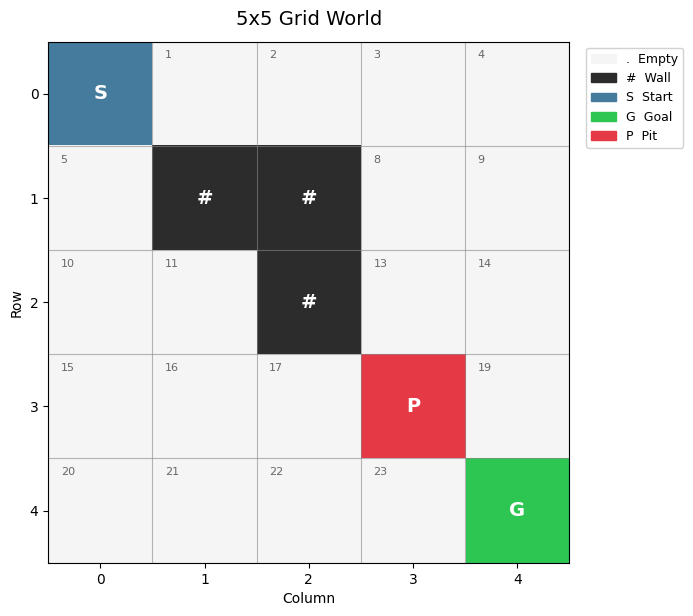

In [14]:
def plot_5grid(values=None, policy=None, title="5x5 Grid World"):
    grid_data = np.full((grid_size, grid_size), ".", dtype="<U1")

    for s in wall_states:
        r, c = state_to_pos(s)
        grid_data[r, c] = "#"

    r, c = state_to_pos(pit_grid)
    grid_data[r, c] = "P"

    r, c = state_to_pos(x_0)
    grid_data[r, c] = "S"

    r, c = state_to_pos(goal_grid)
    grid_data[r, c] = "G"

    mapping = {".": 0, "#": 1, "S": 2, "G": 3, "P": 4}
    labels = {0: "Empty", 1: "Wall", 2: "Start", 3: "Goal", 4: "Pit"}
    colors = ["#F5F5F5", "#2C2C2C", "#457B9D", "#2DC653", "#E63946"]

    numeric_grid = np.vectorize(mapping.get)(grid_data)
    cmap = mcolors.ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(
        numeric_grid,
        cmap=cmap,
        vmin=0,
        vmax=4,
        interpolation="nearest",
        origin="upper",
    )

    ax.set_xticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.grid(which="minor", color="#888888", linewidth=0.8, alpha=0.6)
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.set_xticks(np.arange(grid_size))
    ax.set_yticks(np.arange(grid_size))
    ax.set_xlabel("Column", fontsize=10)
    ax.set_ylabel("Row", fontsize=10)

    if values is not None:
        if hasattr(values, "detach"):
            values = values.detach().cpu().numpy()
        values = np.asarray(values).reshape(-1)

    if policy is not None:
        if hasattr(policy, "detach"):
            policy = policy.detach().cpu().numpy()
        policy = np.asarray(policy)
        best_actions = policy.argmax(axis=1) if policy.ndim == 2 else policy

    arrow_delta = {
        0: (0.0, -0.28),  # Up
        1: (0.0, 0.28),   # Down
        2: (-0.28, 0.0),  # Left
        3: (0.28, 0.0),   # Right
    }

    for s in range(N):
        r, c = state_to_pos(s)

        if s == goal_grid:
            ax.text(c, r, "G", ha="center", va="center", fontsize=14, fontweight="bold", color="white")
        elif s == pit_grid:
            ax.text(c, r, "P", ha="center", va="center", fontsize=14, fontweight="bold", color="white")
        elif s in wall_states:
            ax.text(c, r, "#", ha="center", va="center", fontsize=14, fontweight="bold", color="white")
        elif s == x_0:
            ax.text(c, r, "S", ha="center", va="center", fontsize=14, fontweight="bold", color="white")
        else:
            ax.text(c - 0.38, r - 0.34, str(s), fontsize=8, color="#666666")

        if values is not None and s not in wall_states:
            ax.text(c, r + 0.28, f"{values[s]:.2f}", ha="center", va="center", fontsize=9)

        if policy is not None and s not in terminal_states and s not in wall_states:
            dx, dy = arrow_delta[int(best_actions[s])]
            ax.arrow(
                c,
                r,
                dx,
                dy,
                head_width=0.10,
                head_length=0.10,
                fc="black",
                ec="black",
                linewidth=1.4,
                length_includes_head=True,
                zorder=5,
            )

    patches = [
        mpatches.Patch(color=colors[i], label=f"{symbol}  {labels[i]}")
        for symbol, i in mapping.items()
    ]

    ax.legend(
        handles=patches,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=9,
        framealpha=0.9,
    )

    ax.set_title(title, fontsize=14, pad=12)
    plt.tight_layout()
    plt.show()


plot_5grid()

## Data 

The stochastic grid uses its own fixed offline batch, generated with the same behaviour-policy mixture and reset protocol as the deterministic case.

In [21]:
# Initialize the clean collector.
# every episode starts from state 0.
collector = DiscreteDataBuffer(
    mdp=mdp,
    reset_probs={"occupancy": 1.0},
    occupancy=planner.mu_star,          # shape N*A is accepted
    restricted_states=wall_states,
    max_steps=50,
    terminal_states={goal_grid, pit_grid},
    seed=SEED,
)

# Epsilon-greedy around the optimal policy.
# epsilon=0.3 means 70% planner.pi_star, 30% random action.
epsilon_policy = (planner.pi_star, 0.3)

df = collector.collect(
    policies=[epsilon_policy, "random"],
    proportions=[0.8, 0.2],
    n_steps=8000,
    extra_terminal_steps=3,
    episode_based=True,
    save_path=str(dataset_path_5grid_stoch),
    verbose=True,
)

df.head()

Collected 8000 transitions over 523 episodes.
Policy distribution:
policy_id
0    0.638375
1    0.361625
Name: proportion, dtype: float64
Reset mode distribution:
reset_mode
occupancy    1.0
Name: proportion, dtype: float64
Saved FOGAS dataset to /shared/home/mauro.diaz/work/FOGAS/data/datasets/generalization/5grid_stochastic.csv


,episode,step,state,action,reward,next_state,policy_id,reset_mode,restricted_start
0,0,0,10,0,-0.1,5,1,occupancy,False
1,0,1,5,2,-0.1,10,1,occupancy,False
2,0,2,10,2,-0.1,10,1,occupancy,False
3,0,3,10,3,-0.1,11,1,occupancy,False
4,0,4,11,3,-0.1,11,1,occupancy,False


## Solver

The solver architecture is kept aligned with the deterministic experiment. The output compares the stochastic solver policy with its greedy version and the optimal reference policy.

In [30]:
NN_SEED = 123
EVAL_SEED = 42

random.seed(NN_SEED)
np.random.seed(NN_SEED)
torch.manual_seed(NN_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(NN_SEED)

state_inputs = torch.tensor(
    [[r / 4.0, c / 4.0] for r in range(grid_size) for c in range(grid_size)],
    dtype=torch.float64,
)

hidden_sizes = (8,)

u_param = NeuralUParam(
    StateActionMLPModule(
        n_states=N,
        n_actions=A,
        state_inputs=state_inputs,
        hidden_sizes=hidden_sizes,
        dtype=torch.float64,
    )
)

q_param = NeuralQParam(
    StateActionMLPModule(
        n_states=N,
        n_actions=A,
        state_inputs=state_inputs,
        hidden_sizes=hidden_sizes,
        dtype=torch.float64,
    )
)

policy_param = NeuralPolicyParam(
    StateMLPPolicyModule(
        n_states=N,
        n_actions=A,
        state_inputs=state_inputs,
        hidden_sizes=hidden_sizes,
        dtype=torch.float64,
    )
)

solver_e_stoch = FinalParametrizedSolver(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    x0=x_0,
    csv_path=dataset_path_5grid_stoch,
    u_param=u_param,
    q_param=q_param,
    policy_param=policy_param,
    seed=NN_SEED,
    device=DEVICE,

    theta_include_beta_cov=False,

    theta_mode="reg_fixed",
    theta_lambda=1e-5,
    theta_optimizer="adam",
    theta_inner_steps=2,
    theta_lr=3e-2,
    theta_start_mode="warm",

    beta_update="fogas_diag",
    beta_reg=1e-3,
)

solver_e_stoch.run(
    alpha=5e-4,
    eta=1e-5,
    rho=5,
    policy_optimizer="adam",
    policy_gradient="reinforce",
    reinforce_samples=1,
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    T=2000,
    state_weight_update="normal",
)

mdp.print_policy(solver_e_stoch.pi)

evaluator_stoch = FOGASEvaluator(
    solver=solver_e_stoch,
    mdp=mdp,
    planner=planner,
)

solver_stats = evaluator_stoch.average_return_stats(
    policy_mode="solver",
    num_trajectories=100,
    max_steps=20,
    seed=EVAL_SEED,
    terminal_states=terminal_states,
    compare_with_optimal=True,
)

greedy_stats = evaluator_stoch.average_return_stats(
    policy_mode="greedy",
    num_trajectories=100,
    max_steps=20,
    seed=EVAL_SEED,
    terminal_states=terminal_states,
    compare_with_optimal=True,
)

print(f"Solver avg reward:  {solver_stats['policy']:.4f} +- {solver_stats['policy_std']:.4f}")
print(f"Greedy avg reward:  {greedy_stats['policy']:.4f} +- {greedy_stats['policy_std']:.4f}")
print(f"Optimal avg reward: {solver_stats['optimal']:.4f} +- {solver_stats['optimal_std']:.4f}")

[FinalParametrizedSolver] Iter 1/2000 iter=0 total_loss=-9.444199e-02 policy_objective=8.805221e-02 beta_objective=-6.431916e-02 q_objective=-6.642531e-02 policy_grad_norm=3.815453e-02 policy_direction_norm=3.815453e-02 beta_grad_norm=2.983561e-01 beta_direction_norm=1.482779e+01 theta_grad_norm=2.417130e-01 theta_norm=2.036461e+00 theta_mode=reg_fixed theta_optimizer=adam theta_start_mode=warm theta_lambda=1.000000e-05 theta_lr=3.000000e-02 theta_include_beta_cov=False policy_optimizer=adam policy_gradient=reinforce policy_direction=adam_gradient reinforce_samples=1 D_theta=2.549510e+01 effective_D_theta=2.549510e+01 u_fast_path=False q_fast_path=False policy_fast_path=False beta_update=fogas_diag beta_diag_min=2.836026e-03 beta_diag_max=1.001000e+00
[FinalParametrizedSolver] Iter 51/2000 iter=50 total_loss=-5.634087e+00 policy_objective=1.873941e-01 beta_objective=-2.823914e+00 q_objective=-5.618845e+00 policy_grad_norm=3.624358e+00 policy_direction_norm=3.624358e+00 beta_grad_norm=1